<a href="https://colab.research.google.com/github/felipealencar/courses/blob/artificial-intelligence/artificial-intelligence/lec-04/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 04 — Regression: modeling a continuous target

**Course:** Artificial Intelligence · prof. Felipe Alencar · IFAL — Arapiraca

## Learning objectives
1. Understand **supervised regression**: learning a function `f(x) ≈ y` for a
   continuous target `y`.
2. Fit and interpret **linear** and **polynomial** regression with
   `scikit-learn`.
3. Evaluate fit with **R²** and **RMSE**, and use a model to make predictions.
4. Explore a real scientific relationship: **atmospheric CO₂ vs. global
   temperature**.

## Datasets
- **NOAA Mauna Loa** annual CO₂ (ppm), 1959– ([card](../../datasets/maunaloa_co2_annual.DATASET.md))
- **NASA GISTEMP** global temperature anomaly (°C) ([card](../../datasets/gistemp_global_annual.DATASET.md))

In [1]:
import os
import pandas as pd

# Make plots show up inline and look consistent across the course.
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9, 5)

RAW_BASE = ("https://raw.githubusercontent.com/felipealencar/courses/"
            "artificial-intelligence/datasets/")

def load_dataset(name):
    """Load a course dataset by file name from the local catalog or GitHub."""
    here = os.getcwd()
    for _ in range(6):
        local = os.path.join(here, "datasets", name)
        if os.path.exists(local):
            return pd.read_csv(local)
        here = os.path.dirname(here)
    return pd.read_csv(RAW_BASE + name)  # Colab / standalone fallback


In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error

co2 = load_dataset("maunaloa_co2_annual.csv")
temp = load_dataset("gistemp_global_annual.csv")
co2.head()

,year,co2_ppm,uncertainty_ppm
0,1959,315.98,0.12
1,1960,316.91,0.12
2,1961,317.64,0.12
3,1962,318.45,0.12
4,1963,318.99,0.12


## Part 1 — How fast is CO₂ rising?

We model CO₂ concentration as a function of the year. Start with a straight line.

In [3]:
X = co2[["year"]].values          # feature matrix (n, 1)
y = co2["co2_ppm"].values          # target

lin = LinearRegression().fit(X, y)
pred = lin.predict(X)

print(f"slope     = {lin.coef_[0]:.3f} ppm per year")
print(f"intercept = {lin.intercept_:.1f} ppm")
print(f"R^2       = {r2_score(y, pred):.4f}")
print(f"RMSE      = {np.sqrt(mean_squared_error(y, pred)):.3f} ppm")

slope     = 1.672 ppm per year
intercept = -2969.3 ppm
R^2       = 0.9806
RMSE      = 4.553 ppm


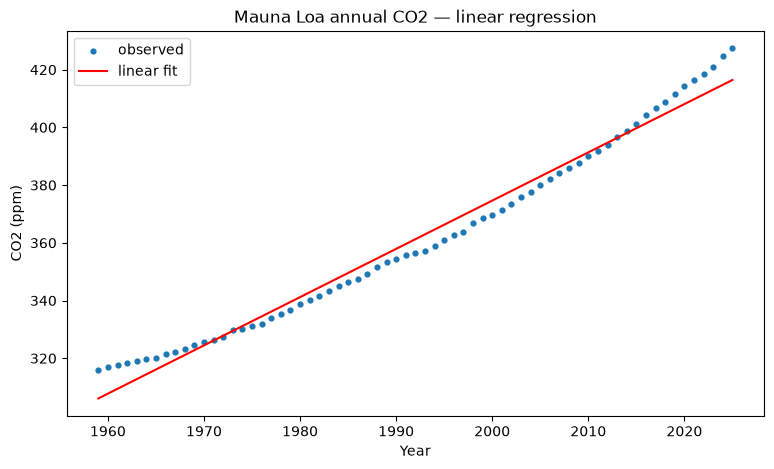

In [4]:
plt.scatter(X, y, s=12, label="observed")
plt.plot(X, pred, color="red", label="linear fit")
plt.title("Mauna Loa annual CO2 — linear regression")
plt.xlabel("Year"); plt.ylabel("CO2 (ppm)"); plt.legend(); plt.show()

The line fits well (high R²) but notice the residuals: the data **curves
upward** — CO₂ is accelerating. A degree-2 **polynomial** captures that.

linear     R^2 = 0.9806
quadratic  R^2 = 0.9995


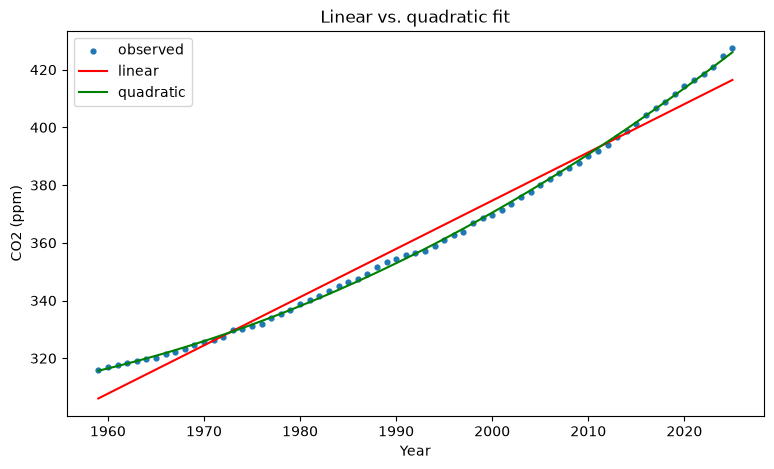

In [5]:
poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression()).fit(X, y)
pred2 = poly.predict(X)
print(f"linear     R^2 = {r2_score(y, pred):.4f}")
print(f"quadratic  R^2 = {r2_score(y, pred2):.4f}")

plt.scatter(X, y, s=12, label="observed")
plt.plot(X, pred, color="red", label="linear")
plt.plot(X, pred2, color="green", label="quadratic")
plt.title("Linear vs. quadratic fit"); plt.xlabel("Year"); plt.ylabel("CO2 (ppm)")
plt.legend(); plt.show()

### Predict the near future

A fitted model can extrapolate — carefully. Let's project CO₂ for 2030.

In [6]:
future = np.array([[2030]])
print(f"Projected 2030 CO2 (linear)    : {lin.predict(future)[0]:.1f} ppm")
print(f"Projected 2030 CO2 (quadratic) : {poly.predict(future)[0]:.1f} ppm")
print("Note: extrapolation assumes the past trend continues — a strong assumption.")

Projected 2030 CO2 (linear)    : 424.8 ppm
Projected 2030 CO2 (quadratic) : 439.2 ppm
Note: extrapolation assumes the past trend continues — a strong assumption.


## Part 2 — Does CO₂ explain temperature?

Now `x = CO₂` and `y = temperature anomaly`. We join the two datasets on `year`.

In [7]:
merged = co2.merge(temp, on="year")
print("overlapping years:", merged.shape[0], f"({merged.year.min()}–{merged.year.max()})")

Xc = merged[["co2_ppm"]].values
yt = merged["temp_anomaly_c"].values
reg = LinearRegression().fit(Xc, yt)
pt = reg.predict(Xc)
print(f"slope = {reg.coef_[0]*100:.3f} °C per 100 ppm CO2")
print(f"R^2   = {r2_score(yt, pt):.4f}")

overlapping years: 67 (1959–2025)
slope = 1.086 °C per 100 ppm CO2
R^2   = 0.9358


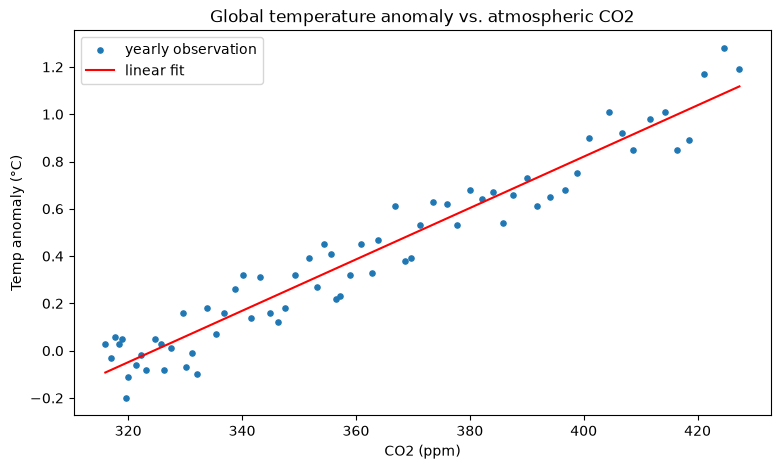

In [8]:
plt.scatter(Xc, yt, s=14, label="yearly observation")
order = Xc[:,0].argsort()
plt.plot(Xc[order], pt[order], color="red", label="linear fit")
plt.title("Global temperature anomaly vs. atmospheric CO2")
plt.xlabel("CO2 (ppm)"); plt.ylabel("Temp anomaly (°C)"); plt.legend(); plt.show()

## What did we learn?

- **Regression** fits a continuous target; `scikit-learn`'s API is always
  `model.fit(X, y)` then `model.predict(X)`.
- **R²** (closer to 1 is better) and **RMSE** (lower is better, in the target's
  units) quantify fit.
- A **polynomial** is still a *linear model in its coefficients* — we just
  expanded the features. It captured the acceleration a straight line missed.
- CO₂ alone explains a large share of the variance in global temperature — a
  correlation with strong physical backing, though *correlation is not proof of
  causation* (a key discussion point).

### Exercises
1. Fit polynomials of degree 1–5 to the CO₂–year data. Plot **training RMSE** vs.
   degree. Why does higher degree always lower training error — and why is that
   dangerous? (We formalize this as *overfitting* in lecture 06.)
2. Split the CO₂ data into *before 2000* (train) and *2000+* (test). Fit on train,
   measure RMSE on test. Does the linear or quadratic model generalize better?
3. Add `year` as a second feature in the temperature model
   (`X = [co2_ppm, year]`). Does R² improve? What does that suggest about
   *confounding*?
4. **Discuss:** the model says +X °C per 100 ppm. List two reasons this simple
   regression should *not* be read as a complete climate model.